In [2]:
import os
os.environ.pop("TF_USE_LEGACY_KERAS", None)


import librosa
%matplotlib inline
import matplotlib.pyplot as plt
import librosa.display
from IPython.display import Audio
import numpy as np
import tensorflow as tf
from matplotlib.pyplot import specgram
import pandas as pd
from sklearn.metrics import confusion_matrix
import IPython.display as ipd
import sys

data = pd.read_csv('../../data/featureRavdess.csv')

In [ ]:
import numpy as np
import random

np.random.seed(42)
random.seed(42)

In [3]:
data

,0,1,2,3,4,5,6,7,8,9,...,186,187,188,189,190,191,192,0.1,0.2,speaker
0,-673.301697,69.508095,-3.494582,18.998575,5.041687,4.626438,-7.605268,-0.057042,-16.231766,-0.299419,...,31.995356,-0.051473,0.025316,-0.044013,-0.079353,0.022513,0.010037,1,1,1
1,-663.297852,67.747589,-6.961255,22.244839,5.313937,2.970508,-6.046401,-3.327282,-17.383774,0.806942,...,31.223174,-0.079423,0.034342,-0.070702,-0.074578,0.025509,-0.001626,1,1,1
2,-664.776184,70.703842,-4.903909,18.797665,1.573513,4.084437,-6.752044,-3.895945,-15.839313,-2.361090,...,31.753796,-0.024101,-0.010724,-0.007700,0.022802,-0.000364,0.032532,1,1,1
3,-660.674133,69.261803,-1.020717,19.743364,3.635317,6.417199,-5.448439,-4.090719,-15.130262,-1.551855,...,30.522612,-0.065819,0.008619,0.004848,-0.030447,-0.000754,0.014753,1,1,1
4,-699.495178,76.727394,-1.602398,21.554548,4.587931,6.054961,-8.122147,-1.003357,-15.158166,-2.688365,...,31.293542,-0.070505,0.011104,0.031151,-0.115693,0.024391,0.003346,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1435,-558.443298,34.201637,-25.876736,3.420890,-22.962826,-6.289969,-22.845768,-13.475706,-11.609130,-4.602691,...,31.661293,-0.020466,0.014107,0.020899,0.050697,-0.005623,0.022015,0,8,24
1436,-509.914642,49.378990,-22.979485,-0.832579,-23.050257,-10.238819,-17.452888,-8.696088,-14.158811,0.367432,...,31.846921,-0.040751,0.017479,0.014917,0.015533,0.016873,-0.000375,0,8,24
1437,-517.733276,40.459633,-27.217442,2.902560,-22.611633,-14.189220,-19.589163,-8.899709,-12.807209,3.745601,...,31.628901,-0.032364,0.032572,-0.050994,0.009171,0.007204,0.013219,0,8,24
1438,-463.998352,35.496925,-14.260783,9.399699,-19.878208,0.799514,-18.052525,-4.351163,-7.299998,0.214021,...,31.137002,-0.045889,0.027680,-0.042989,-0.060098,0.005997,-0.009220,0,8,24


In [4]:
import joblib

# Load the saved scaler
scaler = joblib.load("../scaler.pkl")

# Load the saved model
gender_model = tf.keras.models.load_model("../gender_classification_model.h5")

W0000 00:00:1761901227.217408 2640996 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [5]:
X_gender = data.iloc[:, :193].values
X_scaled = scaler.transform(X_gender)
gender_predictions = gender_model.predict(X_scaled)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 562us/step


In [6]:
print(gender_predictions)

[[5.5358798e-04]
 [5.8018899e-04]
 [1.0596259e-03]
 ...
 [9.9961776e-01]
 [9.9903077e-01]
 [9.9929035e-01]]


In [7]:
male_rows = gender_predictions.flatten() < 0.5  # 0 for Male, 1 for Female

df = data[male_rows]

print(f"Filtered dataset contains {df.shape[0]} male samples.")

Filtered dataset contains 719 male samples.


In [8]:
df.shape

(719, 196)

In [9]:
df

,0,1,2,3,4,5,6,7,8,9,...,186,187,188,189,190,191,192,0.1,0.2,speaker
0,-673.301697,69.508095,-3.494582,18.998575,5.041687,4.626438,-7.605268,-0.057042,-16.231766,-0.299419,...,31.995356,-0.051473,0.025316,-0.044013,-0.079353,0.022513,0.010037,1,1,1
1,-663.297852,67.747589,-6.961255,22.244839,5.313937,2.970508,-6.046401,-3.327282,-17.383774,0.806942,...,31.223174,-0.079423,0.034342,-0.070702,-0.074578,0.025509,-0.001626,1,1,1
2,-664.776184,70.703842,-4.903909,18.797665,1.573513,4.084437,-6.752044,-3.895945,-15.839313,-2.361090,...,31.753796,-0.024101,-0.010724,-0.007700,0.022802,-0.000364,0.032532,1,1,1
3,-660.674133,69.261803,-1.020717,19.743364,3.635317,6.417199,-5.448439,-4.090719,-15.130262,-1.551855,...,30.522612,-0.065819,0.008619,0.004848,-0.030447,-0.000754,0.014753,1,1,1
4,-699.495178,76.727394,-1.602398,21.554548,4.587931,6.054961,-8.122147,-1.003357,-15.158166,-2.688365,...,31.293542,-0.070505,0.011104,0.031151,-0.115693,0.024391,0.003346,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1375,-518.176025,54.336693,-16.867956,2.470917,-4.073838,-2.748888,-13.374091,-6.024971,-16.421869,-2.043707,...,31.550327,-0.011495,0.014177,-0.008497,-0.027965,-0.001463,0.007953,1,8,23
1376,-502.163391,49.330410,-16.674372,6.953362,-1.735307,-1.708595,-17.710266,-5.345790,-14.760635,-1.683560,...,31.989208,-0.043424,0.013255,-0.030656,0.050061,0.003688,0.007049,1,8,23
1377,-499.994263,50.926987,-19.440176,3.803090,-7.180909,-2.145453,-16.375141,-6.704348,-15.546900,-1.911119,...,32.237853,-0.059843,0.048440,-0.045319,0.020689,0.010588,0.016066,1,8,23
1378,-481.682251,41.021809,-19.435980,-0.163736,-10.369910,-2.922106,-15.791293,-7.187538,-15.690004,-3.325412,...,31.312768,-0.032609,0.030134,-0.100309,0.004273,-0.013313,-0.004990,1,8,23


In [10]:
X = df.iloc[:, :-3].copy()
y = df.iloc[:,-2].copy()

In [11]:
X

,0,1,2,3,4,5,6,7,8,9,...,183,184,185,186,187,188,189,190,191,192
0,-673.301697,69.508095,-3.494582,18.998575,5.041687,4.626438,-7.605268,-0.057042,-16.231766,-0.299419,...,14.502933,15.547618,17.645388,31.995356,-0.051473,0.025316,-0.044013,-0.079353,0.022513,0.010037
1,-663.297852,67.747589,-6.961255,22.244839,5.313937,2.970508,-6.046401,-3.327282,-17.383774,0.806942,...,15.213718,15.513745,17.582760,31.223174,-0.079423,0.034342,-0.070702,-0.074578,0.025509,-0.001626
2,-664.776184,70.703842,-4.903909,18.797665,1.573513,4.084437,-6.752044,-3.895945,-15.839313,-2.361090,...,14.972030,15.697508,17.437520,31.753796,-0.024101,-0.010724,-0.007700,0.022802,-0.000364,0.032532
3,-660.674133,69.261803,-1.020717,19.743364,3.635317,6.417199,-5.448439,-4.090719,-15.130262,-1.551855,...,15.242136,15.597314,16.492804,30.522612,-0.065819,0.008619,0.004848,-0.030447,-0.000754,0.014753
4,-699.495178,76.727394,-1.602398,21.554548,4.587931,6.054961,-8.122147,-1.003357,-15.158166,-2.688365,...,14.636722,16.023571,17.020093,31.293542,-0.070505,0.011104,0.031151,-0.115693,0.024391,0.003346
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1375,-518.176025,54.336693,-16.867956,2.470917,-4.073838,-2.748888,-13.374091,-6.024971,-16.421869,-2.043707,...,15.563899,16.786573,17.289161,31.550327,-0.011495,0.014177,-0.008497,-0.027965,-0.001463,0.007953
1376,-502.163391,49.330410,-16.674372,6.953362,-1.735307,-1.708595,-17.710266,-5.345790,-14.760635,-1.683560,...,15.518351,17.003934,17.874535,31.989208,-0.043424,0.013255,-0.030656,0.050061,0.003688,0.007049
1377,-499.994263,50.926987,-19.440176,3.803090,-7.180909,-2.145453,-16.375141,-6.704348,-15.546900,-1.911119,...,15.092518,16.634495,17.128656,32.237853,-0.059843,0.048440,-0.045319,0.020689,0.010588,0.016066
1378,-481.682251,41.021809,-19.435980,-0.163736,-10.369910,-2.922106,-15.791293,-7.187538,-15.690004,-3.325412,...,15.157907,16.104991,16.717183,31.312768,-0.032609,0.030134,-0.100309,0.004273,-0.013313,-0.004990


In [12]:
y

0       1
1       1
2       1
3       1
4       2
       ..
1375    8
1376    8
1377    8
1378    8
1379    8
Name: 0.2, Length: 719, dtype: int64

In [13]:
X.shape, y.shape

((719, 193), (719,))

In [14]:
from keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
lb = LabelEncoder()
y1 = to_categorical(lb.fit_transform(y))

In [15]:
y1

array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], shape=(719, 8))

In [16]:
X.shape, y1.shape

((719, 193), (719, 8))

In [17]:
X2=X.copy().to_numpy()
y2=y.copy().to_numpy()

In [18]:
X2.shape, y2.shape

((719, 193), (719,))

In [19]:
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from matplotlib.pyplot import specgram
import keras

from keras.preprocessing import sequence
from keras.models import Sequential
from keras.layers import Dense, Embedding, Activation
from keras.layers import LSTM

from keras.utils import to_categorical
from keras.layers import Input, Flatten, Dropout#, Activation
from keras.layers import Conv1D, MaxPooling1D, AveragePooling1D
from keras.models import Model
from keras.callbacks import ModelCheckpoint
from sklearn.metrics import confusion_matrix
from keras.layers import BatchNormalization

def model1(input_shape1):
    model = Sequential()

    model.add(Conv1D(256, 5,padding='same',
                     input_shape=(input_shape1,1)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))


    model.add(Conv1D(256, 5,padding='same'))
    model.add(Activation('relu'))
    model.add(Dropout(0.1))

    model.add(BatchNormalization())

    model.add(MaxPooling1D(pool_size=(8)))
    model.add(Conv1D(256, 5,padding='same',))

    model.add(Activation('relu'))

    model.add(Conv1D(128, 5,padding='same',))
    model.add(Activation('relu'))
    model.add(Conv1D(128, 5,padding='same',))
    model.add(BatchNormalization())

    model.add(Activation('relu'))
    model.add(Dropout(0.2))

    model.add(Flatten())
    model.add(Dropout(0.2))
    model.add(Dense(8))
    model.add(BatchNormalization())
    model.add(Activation('softmax'))

    return model

In [20]:
import random, numpy as np
from keras import optimizers
kfold=5
def create_index(kfold, size):
    a = []
    for i in range(size):
        a.append(i)
    random.shuffle(a)
    arr = np.array(a)
    return arr.reshape(kfold, size//kfold)

In [21]:
X3=pd.DataFrame(X2)
X3

,0,1,2,3,4,5,6,7,8,9,...,183,184,185,186,187,188,189,190,191,192
0,-673.301697,69.508095,-3.494582,18.998575,5.041687,4.626438,-7.605268,-0.057042,-16.231766,-0.299419,...,14.502933,15.547618,17.645388,31.995356,-0.051473,0.025316,-0.044013,-0.079353,0.022513,0.010037
1,-663.297852,67.747589,-6.961255,22.244839,5.313937,2.970508,-6.046401,-3.327282,-17.383774,0.806942,...,15.213718,15.513745,17.582760,31.223174,-0.079423,0.034342,-0.070702,-0.074578,0.025509,-0.001626
2,-664.776184,70.703842,-4.903909,18.797665,1.573513,4.084437,-6.752044,-3.895945,-15.839313,-2.361090,...,14.972030,15.697508,17.437520,31.753796,-0.024101,-0.010724,-0.007700,0.022802,-0.000364,0.032532
3,-660.674133,69.261803,-1.020717,19.743364,3.635317,6.417199,-5.448439,-4.090719,-15.130262,-1.551855,...,15.242136,15.597314,16.492804,30.522612,-0.065819,0.008619,0.004848,-0.030447,-0.000754,0.014753
4,-699.495178,76.727394,-1.602398,21.554548,4.587931,6.054961,-8.122147,-1.003357,-15.158166,-2.688365,...,14.636722,16.023571,17.020093,31.293542,-0.070505,0.011104,0.031151,-0.115693,0.024391,0.003346
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
714,-518.176025,54.336693,-16.867956,2.470917,-4.073838,-2.748888,-13.374091,-6.024971,-16.421869,-2.043707,...,15.563899,16.786573,17.289161,31.550327,-0.011495,0.014177,-0.008497,-0.027965,-0.001463,0.007953
715,-502.163391,49.330410,-16.674372,6.953362,-1.735307,-1.708595,-17.710266,-5.345790,-14.760635,-1.683560,...,15.518351,17.003934,17.874535,31.989208,-0.043424,0.013255,-0.030656,0.050061,0.003688,0.007049
716,-499.994263,50.926987,-19.440176,3.803090,-7.180909,-2.145453,-16.375141,-6.704348,-15.546900,-1.911119,...,15.092518,16.634495,17.128656,32.237853,-0.059843,0.048440,-0.045319,0.020689,0.010588,0.016066
717,-481.682251,41.021809,-19.435980,-0.163736,-10.369910,-2.922106,-15.791293,-7.187538,-15.690004,-3.325412,...,15.157907,16.104991,16.717183,31.312768,-0.032609,0.030134,-0.100309,0.004273,-0.013313,-0.004990


In [22]:
from skfeature.function.similarity_based import fisher_score
from keras.callbacks import EarlyStopping
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

hist=[]
scores=[]
totalsize=715
num_fea=125
a=create_index(kfold,totalsize)
savedir='ravdess_gender_male_193'

# Stratified K-Fold setup
skf = StratifiedKFold(n_splits=kfold, shuffle=True, random_state=42)

fold = 0
for train_idx, test_idx in skf.split(X3, y2):
    print(f"\n===== Fold {fold} =====")
    print(f"Train: {len(train_idx)} | Test: {len(test_idx)}")

    # Split data
    X_train, X_test = X3.iloc[train_idx, :], X3.iloc[test_idx, :]
    y_train, y_test = y1[train_idx, :], y1[test_idx, :]
    y_train_fs, y_test_fs = y2[train_idx], y2[test_idx]  # for fisher score

    # Scale separately
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Fisher score feature selection (on training data only)
    score = fisher_score.fisher_score(X_train_scaled, y_train_fs)
    sorted_indices = np.argsort(score)[::-1]
    fs_indices = sorted_indices[:num_fea]

    print(f"Top {num_fea} features: {fs_indices[:10]} ...")

    # Select top features
    X_train_fs = X_train_scaled[:, fs_indices]
    X_test_fs = X_test_scaled[:, fs_indices]

    # CNN input shape adjustment
    x_traincnn = np.expand_dims(X_train_fs, axis=2)
    x_testcnn = np.expand_dims(X_test_fs, axis=2)

    # Build and compile model
    m1 = model1(x_traincnn.shape[1])
    opt = tf.keras.optimizers.RMSprop(learning_rate=0.00005, decay=1e-6)
    m1.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

    early_stopping = EarlyStopping(monitor='val_accuracy', patience=700, restore_best_weights=True)

    # Train
    history = m1.fit(
        x_traincnn, y_train,
        batch_size=32, epochs=700,
        validation_data=(x_testcnn, y_test),
        callbacks=[early_stopping],
        verbose=1
    )
    hist.append(history)

    # Evaluate
    score_eval = m1.evaluate(x_testcnn, y_test, verbose=0)
    scores.append(score_eval)
    print(f"Fold {fold} Test Accuracy: {score_eval[1]:.4f}")

    # Save test data for reproducibility
    np.save(os.path.join(savedir, f"X_test_fold{fold}.npy"), x_testcnn)
    np.save(os.path.join(savedir, f"y_test_fold{fold}.npy"), y_test)

    # Save model
    model_name = f"Model_{fold}.h5"
    model_path = os.path.join(savedir, model_name)
    model_json = m1.to_json()
    with open(os.path.join(savedir, f"Model_{fold}.json"), "w") as json_file:
        json_file.write(model_json)
    m1.save(model_path)

    fold += 1

print("\n===== Cross-validation results =====")
for i, sc in enumerate(scores):
    print(f"Fold {i}: Loss={sc[0]:.4f}, Accuracy={sc[1]:.4f}")
print(f"\nAverage accuracy: {np.mean([s[1] for s in scores]):.4f}")
    


===== Fold 0 =====
Train: 575 | Test: 144
Top 125 features: [  0   1   2  19  15  35 140 154  73 165] ...
Epoch 1/700


/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - accuracy: 0.1896 - loss: 2.1757 - val_accuracy: 0.1597 - val_loss: 2.0670
Epoch 2/700
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.2835 - loss: 1.8603 - val_accuracy: 0.1389 - val_loss: 2.0744
Epoch 3/700
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.3652 - loss: 1.7476 - val_accuracy: 0.1389 - val_loss: 2.0807
Epoch 4/700
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.3826 - loss: 1.6422 - val_accuracy: 0.1319 - val_loss: 2.0883
Epoch 5/700
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.4522 - loss: 1.5680 - val_accuracy: 0.1389 - val_loss: 2.0909
Epoch 6/700
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.4817 - loss: 1.5092 - val_accuracy: 0.1389 - val_loss: 2.0965
Epoch 7/700
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.5183 - loss: 1.4732 - val_accuracy: 0.1319 - val_loss: 2.1030
Epoch 8/700
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.5583 - loss: 1.4098 - val_accuracy: 0.1458 - val_l

Fold 0 Test Accuracy: 0.7639

===== Fold 1 =====
Train: 575 | Test: 144
Top 125 features: [  0   1   2  15  13  37 138 150  45 162] ...


/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/700


/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - accuracy: 0.1736 - loss: 2.1762 - val_accuracy: 0.2378 - val_loss: 2.0433
Epoch 2/700
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.2934 - loss: 1.8282 - val_accuracy: 0.1678 - val_loss: 2.0618
Epoch 3/700
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.3715 - loss: 1.7416 - val_accuracy: 0.1608 - val_loss: 2.0785
Epoch 4/700
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.4115 - loss: 1.6465 - val_accuracy: 0.1678 - val_loss: 2.0882
Epoch 5/700
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.4462 - loss: 1.5950 - val_accuracy: 0.1469 - val_loss: 2.1071
Epoch 6/700
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.4740 - loss: 1.5127 - val_accuracy: 0.1678 - val_loss: 2.1141
Epoch 7/700
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.5191 - loss: 1.4468 - val_accuracy: 0.1469 - val_loss: 2.1367
Epoch 8/700
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.5399 - loss: 1.3940 - val_accuracy: 0.1399 - val_l

Fold 4 Test Accuracy: 0.6573

===== Cross-validation results =====
Fold 0: Loss=1.0027, Accuracy=0.7639
Fold 1: Loss=0.9958, Accuracy=0.7431
Fold 2: Loss=1.2399, Accuracy=0.6667
Fold 3: Loss=1.1863, Accuracy=0.7361
Fold 4: Loss=1.2625, Accuracy=0.6573

Average accuracy: 0.7134


In [1]:
import numpy as np
import keras
from keras.models import model_from_json
from sklearn.metrics import confusion_matrix

savedir = 'ravdess_gender_male_193'
num_folds = 5 
opt = keras.optimizers.RMSprop(learning_rate=0.00001, decay=1e-6)

accuracies = []
conf_matrices = []

for i in range(num_folds):
    model_name = f"Model_{i}"

    with open(f"{savedir}/{model_name}.json", "r") as json_file:
        loaded_model = model_from_json(json_file.read())
    loaded_model.load_weights(f"{savedir}/{model_name}.h5")

    loaded_model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

    X_test = np.load(f"{savedir}/X_test_fold{i}.npy")
    y_test = np.load(f"{savedir}/y_test_fold{i}.npy")

    score = loaded_model.evaluate(X_test, y_test, verbose=0)
    acc = score[1] * 100
    accuracies.append(acc)

    y_pred = loaded_model.predict(X_test, verbose=0)
    y_pred_labels = np.argmax(y_pred, axis=1)
    y_true_labels = np.argmax(y_test, axis=1)

    cm = confusion_matrix(y_true_labels, y_pred_labels)
    conf_matrices.append(cm)

    print(f"Fold {i}: Accuracy = {acc:.2f}%")

# array: (num_folds, num_classes, num_classes)
conf_matrices = np.array(conf_matrices)
mean_acc = np.mean(accuracies)

print("\nMean Accuracy: %.2f%%" % mean_acc)
print("SD Accuracy: %.2f" % np.std(accuracies))

n = num_folds
ci95 = 1.96 * (np.std(accuracies) / np.sqrt(n))
ci_low = mean_acc - ci95
ci_high = mean_acc + ci95
print(f"95% CI: [{ci_low:.2f}%, {ci_high:.2f}%]")

2025-11-10 18:09:50.469703: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-10 18:09:50.501060: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-10 18:09:51.189020: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-

Fold 0: Accuracy = 76.39%
Fold 1: Accuracy = 74.31%
Fold 2: Accuracy = 66.67%
Fold 3: Accuracy = 73.61%
Fold 4: Accuracy = 65.73%

Mean Accuracy: 71.34%
SD Accuracy: 4.31
95% CI: [67.57%, 75.12%]


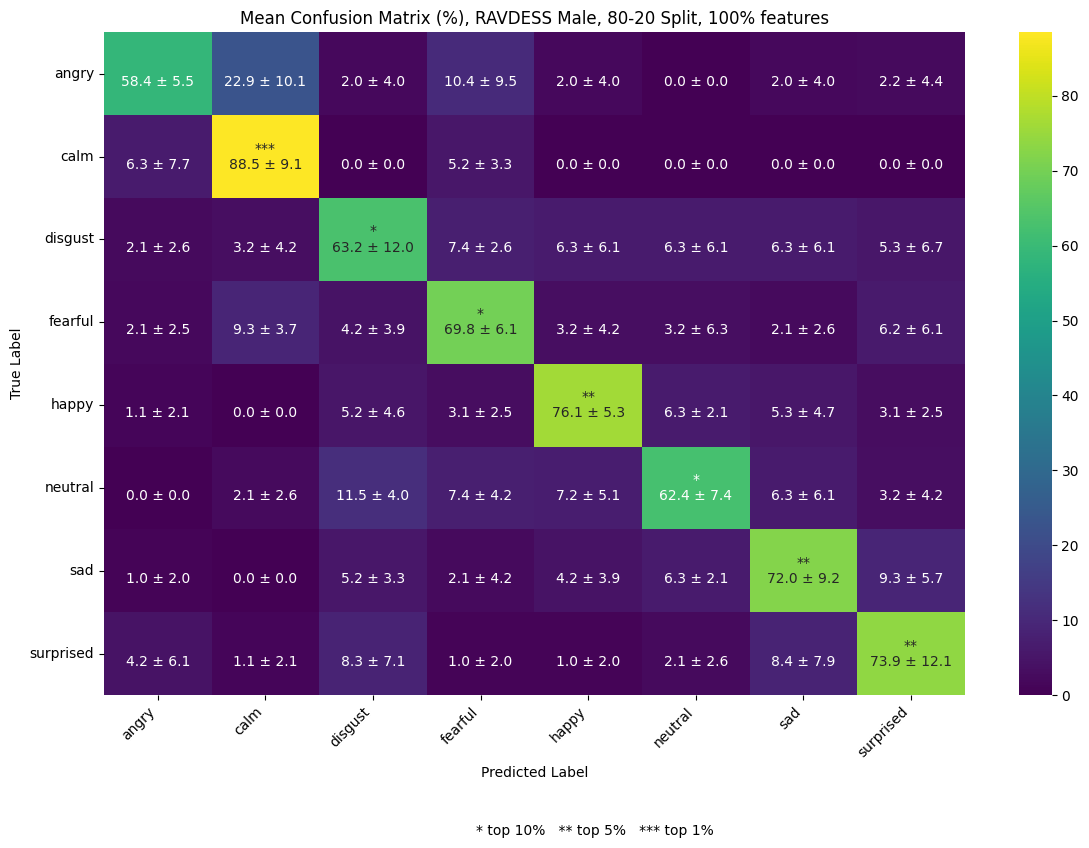

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

conf_matrices_percent = conf_matrices / conf_matrices.sum(axis=2, keepdims=True) * 100

np.save('cm_ravdess_gender_male_193.npy', conf_matrices_percent)


mean_cm = np.mean(conf_matrices_percent, axis=0)
std_cm = np.std(conf_matrices_percent, axis=0)

# Compute percentile thresholds for annotation
flat_vals = mean_cm.flatten()
thr_90 = np.percentile(flat_vals, 90)
thr_95 = np.percentile(flat_vals, 95)
thr_99 = np.percentile(flat_vals, 99)

# Create annotation labels with significance symbols
labels = np.empty(mean_cm.shape, dtype=object)
for i in range(mean_cm.shape[0]):
    for j in range(mean_cm.shape[1]):
        val = mean_cm[i, j]
        symbol = ""
        if val >= thr_99:
            symbol = "***"
        elif val >= thr_95:
            symbol = "**"
        elif val >= thr_90:
            symbol = "*"
        labels[i, j] = f"{symbol}\n{val:.1f} ± {std_cm[i, j]:.1f}"

listik = ['angry', 'calm', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']

# Plot
plt.figure(figsize=(12,8))
ax = sns.heatmap(mean_cm, annot=labels, fmt="", cmap="viridis", cbar=True)

ax.set_xticks(np.arange(len(listik)) + 0.5)
ax.set_yticks(np.arange(len(listik)) + 0.5)
ax.set_xticklabels(listik, rotation=45, ha="right")
ax.set_yticklabels(listik, rotation=0)

plt.title("Mean Confusion Matrix (%), RAVDESS Male, 80-20 Split, 100% features")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.figtext(0.5, -0.05,
            "* top 10%   ** top 5%   *** top 1%",
            ha="center", fontsize=10)
plt.show()
